In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col

import warnings
warnings.filterwarnings("ignore")

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

import semopy
from semopy import Model

from stepmix.stepmix import StepMix
%matplotlib inline

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

# Pregunta 1
Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [2]:
df = pd.read_csv('../../data/junaeb3.csv')
df.describe()

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

Ninguna columna posee suficientes valores nulos como para considerar eliminarla de inmediato.

In [3]:
df.isna().sum()

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

Eliminación de outliers: Eliminamos a quienes tengan un imce menor que -3 o mayor que 3. Eliminamos a quienes tengan 2 cuidadores del mismo género. Eliminamos a los padres que hayan estudiado 20 años o más y 5 o menos. Luego eliminamos las filas con valores nulos.

In [4]:
C=len(df)

df=df[df["imce"]>=-3]
df=df[df["imce"]<=3]

df=df[df["vive_madre"]<2]
df=df[df["vive_padre"]<2]

df=df[df["educm"]<20]
df=df[df["educm"]>5]
df=df[df["educp"]<20]
df=df[df["educp"]>5]

df.dropna(inplace=True)
c=len(df)

print(f'Se han eliminado {C-c} filas')

{"tags": ["hide_input"]}

Se han eliminado 6611 filas


{'tags': ['hide_input']}

La mayoría de los niños tienen un imce entre 0 y 1. No parece haber diferencias por género ni por el área en la que viven ni por su edad.

{'tags': ['hide_input']}

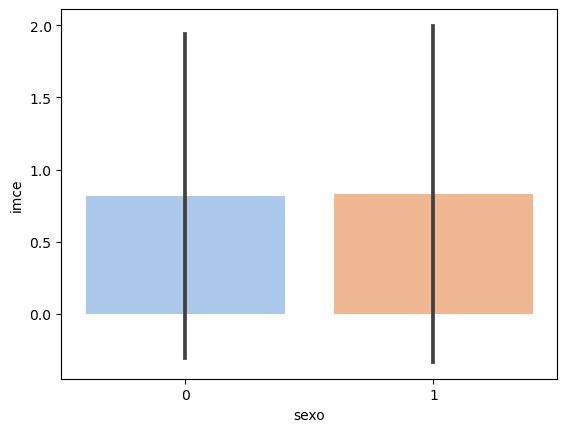

In [5]:
sns.barplot(data=df, x='sexo', y='imce', ci='sd', palette='pastel')

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

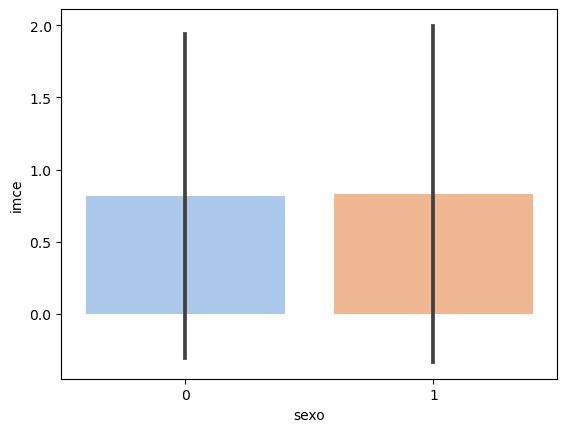

In [6]:
sns.barplot(data=df, x='sexo', y='imce', ci='sd', palette='pastel')

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

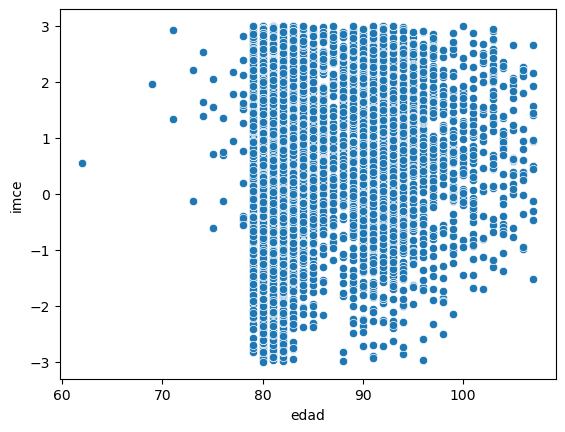

In [7]:
sns.scatterplot(data=df, x='edad', y='imce', palette='pastel')

{"tags": ["hide_input"]}

# Pregunta 2
A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

Cambiamos el sentido de las respuestas de sk7 para que coincida con el resto.

In [8]:
df["sk7"]=abs(df["sk7"]-6)

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

Seleccionamos las variables desde sk1 a sk13 y aplicamos test de esfericidad de Bartlett y KMO. Como vemos más abajo, el valor p del test de Bartlett es <0.05, por lo que los datos son factorizables y el KMO es >0.6, por lo que es apropiada la factorización.

In [9]:
variables = [f'sk{x}' for x in range(1,14)]
df_efa = df[variables]

# Test de esfericidad de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df_efa)
print("Bartlett’s test chi-square:", chi_square_value, "p-value:", p_value)

# Test KMO
kmo_all, kmo_model = calculate_kmo(df_efa)
print("KMO Model:", kmo_model)

{"tags": ["hide_input"]}

Bartlett’s test chi-square: 65015.85718702719 p-value: 0.0
KMO Model: 0.8620597383438388


{'tags': ['hide_input']}

Para ver cuántos factores debemos usar analizamos el siguiente gráfico. Vemos que el codo está en el tercer valor, por lo que solo usaremos 3 factores.

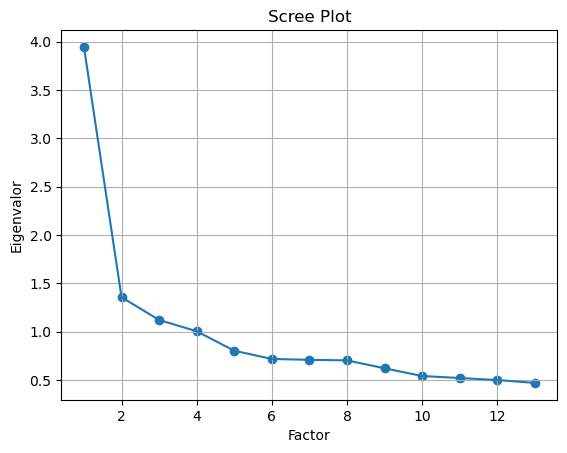

{'tags': ['hide_input']}

In [10]:
fa = FactorAnalyzer(rotation='varimax').fit(df_efa)
ev, v = fa.get_eigenvalues()
plt.scatter(range(1, df_efa.shape[1]+1), ev)
plt.plot(range(1, df_efa.shape[1]+1), ev)
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalor')
plt.grid(True)
plt.show()

{"tags": ["hide_input"]}

### Modelo EFA
Podemos ver que las variables sk9-sk13 se relacionan con el factor 1, las variables sk1-sk4 se relacionan con el factor 2 y las variables sk5-sk8 se relacionan con el factor 3. La variable sk7 no tiene una relación mayor a 0.3 con ningún factor, por lo que podemos decir que no es informativa.

In [11]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(df_efa)
loadings = fa.loadings_
print("Cargas factoriales:\n", loadings)
varianza = fa.get_factor_variance()
print("Varianza explicada:\n", varianza)

{"tags": ["hide_input"]}

Cargas factoriales:
 [[ 0.16785018  0.52547307  0.15086141]
 [ 0.1727029   0.50526692  0.35486957]
 [ 0.17271926  0.58519581  0.1618918 ]
 [ 0.18900917  0.69288237  0.1864869 ]
 [ 0.11585632  0.20902091  0.71734109]
 [ 0.15830825  0.1916527   0.48124968]
 [-0.06920799 -0.06892    -0.14503488]
 [ 0.26730932  0.10330486  0.47310368]
 [ 0.48948946  0.19688986  0.20300555]
 [ 0.54605719  0.11352193  0.12312143]
 [ 0.66691542  0.19353685  0.20331082]
 [ 0.51760407  0.10440606  0.13468062]
 [ 0.46467139  0.15614865  0.12690332]]
Varianza explicada:
 (array([1.70467264, 1.57419148, 1.33266834]), array([0.13112866, 0.12109165, 0.10251295]), array([0.13112866, 0.25222032, 0.35473327]))


{'tags': ['hide_input']}

Al eliminar sk7 obtendremos la matriz siguiente. Las variables siguen perteneciendo a los mismos factores.

In [12]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
df_efa.drop("sk7", axis=1, inplace=True)
fa.fit(df_efa)
loadings = fa.loadings_
print("Cargas factoriales:\n", loadings)
varianza = fa.get_factor_variance()
print("Varianza explicada:\n", varianza)

{"tags": ["hide_input"]}

Cargas factoriales:
 [[0.17140334 0.53373896 0.12054793]
 [0.18361961 0.51955102 0.32138525]
 [0.17362164 0.58746338 0.14896337]
 [0.19046642 0.69493536 0.16853167]
 [0.11874788 0.21982108 0.76429495]
 [0.17605202 0.21401743 0.43409316]
 [0.27981725 0.11946755 0.45899879]
 [0.49373652 0.20375601 0.1849253 ]
 [0.54938224 0.11944032 0.10210797]
 [0.67069647 0.20097612 0.18052154]
 [0.5193415  0.10753885 0.12605059]
 [0.46652634 0.15976805 0.1150026 ]]
Varianza explicada:
 (array([1.73570303, 1.62452051, 1.2580026 ]), array([0.14464192, 0.13537671, 0.10483355]), array([0.14464192, 0.28001863, 0.38485218]))


{'tags': ['hide_input']}

# Pregunta 3
Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

In [13]:
factor_scores = fa.transform(df_efa)
df_factores = pd.DataFrame(factor_scores, columns=['Factor1', 'Factor2', 'Factor3'])

df_factores['sexo'] = df['sexo']
df_factores['area'] = df['area']
df_factores['imce'] = df['imce']
df_factores['act_fisica'] = df['act_fisica']

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

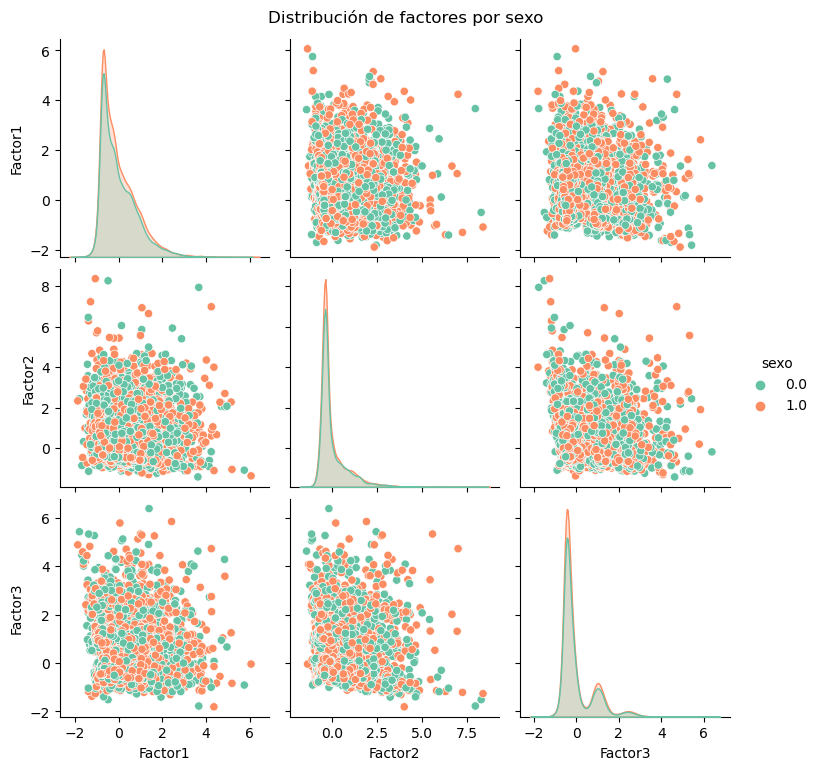

{'tags': ['hide_input']}

In [14]:
sns.pairplot(data=df_factores, vars=['Factor1', 'Factor2', 'Factor3'], hue='sexo', palette='Set2')
plt.suptitle('Distribución de factores por sexo', y=1.02)
plt.show()

{"tags": ["hide_input"]}

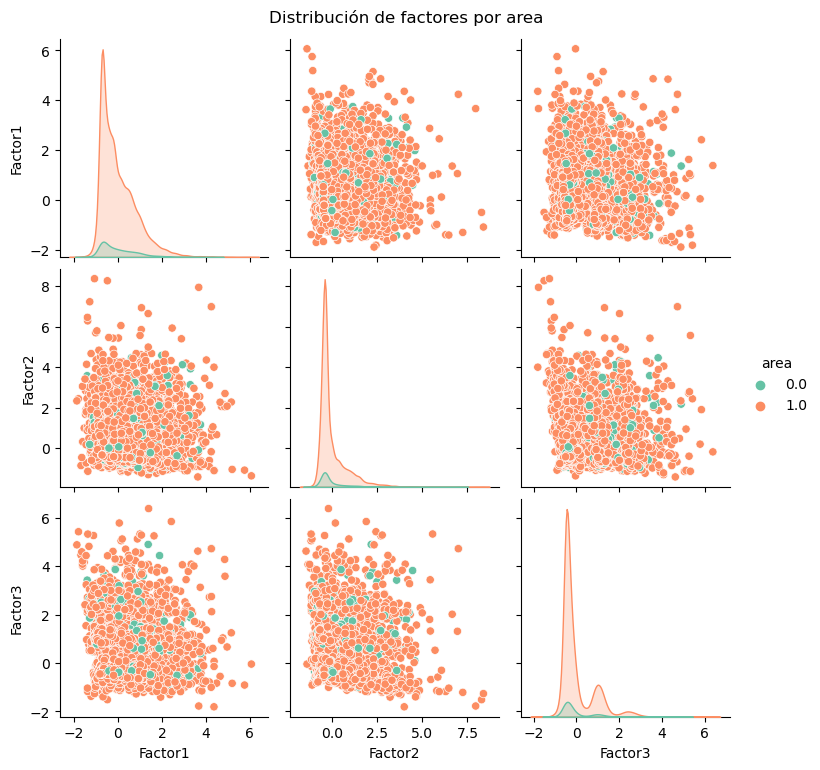

{'tags': ['hide_input']}

In [15]:
sns.pairplot(data=df_factores, vars=['Factor1', 'Factor2', 'Factor3'], hue='area', palette='Set2')
plt.suptitle('Distribución de factores por area', y=1.02)
plt.show()

{"tags": ["hide_input"]}

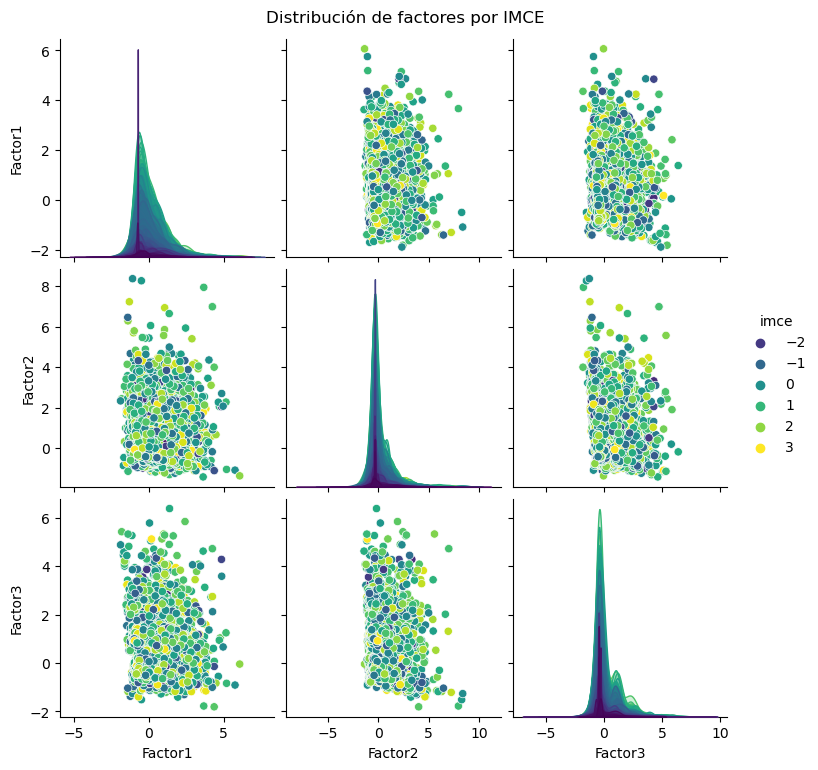

{'tags': ['hide_input']}

In [16]:
sns.pairplot(
    data=df_factores, 
    vars=['Factor1', 'Factor2', 'Factor3'], 
    hue='imce', 
    palette='viridis'
)
plt.suptitle('Distribución de factores por IMCE', y=1.02)
plt.show()

{"tags": ["hide_input"]}

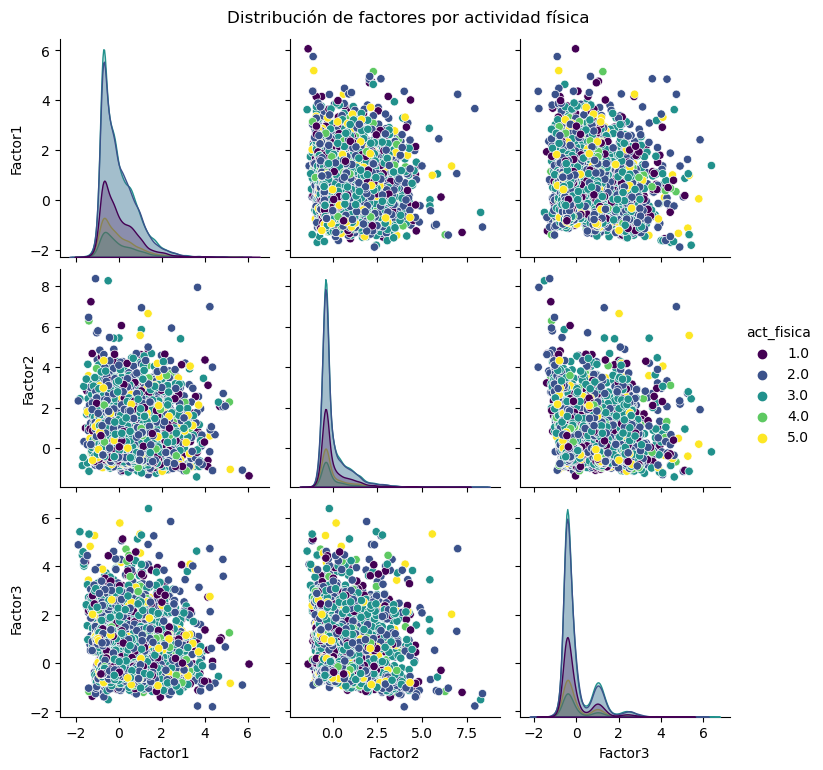

{'tags': ['hide_input']}

In [17]:
sns.pairplot(
    data=df_factores, 
    vars=['Factor1', 'Factor2', 'Factor3'], 
    hue='act_fisica', 
    palette='viridis'
)
plt.suptitle('Distribución de factores por actividad física', y=1.02)
plt.show()

{"tags": ["hide_input"]}

Como podemos ver en los gráficos anteriores, no parece haber patrones de agrupamiento y las curvas de distribución son muy similares entre categorías, por lo quue podriamos decir que las variables escogidas no sirven para discriminar entre los factores.

# Pregunta 4
Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings).

Llamaremos al factor 1 Creatividad y Curiosidad (CyC), al factor 2, desarrollo sentimental (DS) y al facotor 3, Interacciones sociales (IS).
Como podemos ver, todas nuestras variables sk coinciden con el factor que les habíamos asignado previamente, pues sus loadings son mayores a 0.6

In [28]:
model_desc = """
DS =~ sk1+sk2+sk3+sk4
CyC =~ sk9+sk10+sk11+sk12+sk13
IS =~ sk5+sk6+sk8

"""


model = Model(model_desc)
model.fit(df.drop("sk7",axis=1))


estimates = model.inspect()
print(estimates)

{"tags": ["hide_input"]}

    lval  op  rval  Estimate  Std. Err    z-value p-value
0    sk1   ~    DS  1.000000         -          -       -
1    sk2   ~    DS  1.937930  0.027766  69.794213     0.0
2    sk3   ~    DS  1.696794  0.024597  68.982956     0.0
3    sk4   ~    DS  1.915508  0.026025  73.601317     0.0
4    sk9   ~   CyC  1.000000         -          -       -
5   sk10   ~   CyC  1.346123  0.021095   63.81389     0.0
6   sk11   ~   CyC  1.252441  0.016764   74.70994     0.0
7   sk12   ~   CyC  1.103041  0.017666  62.437563     0.0
8   sk13   ~   CyC  1.266844  0.021461  59.030958     0.0
9    sk5   ~    IS  1.000000         -          -       -
10   sk6   ~    IS  1.012746  0.016123  62.814857     0.0
11   sk8   ~    IS  1.177400  0.018382  64.050405     0.0
12   CyC  ~~   CyC  0.142093  0.003244  43.796772     0.0
13   CyC  ~~    DS  0.046326  0.000986  46.967884     0.0
14   CyC  ~~    IS  0.085217  0.001753  48.605862     0.0
15    DS  ~~    DS  0.044190  0.001031   42.85921     0.0
16    DS  ~~  

{'tags': ['hide_input']}

Los CFI, GFI y AGFI son >0.9 por lo que es un buen ajuste.

In [32]:
semopy.calc_stats(model)

{"tags": ["hide_input"]}

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,3389.453374,0.0,63819.671723,0.947635,0.94689,0.93127,0.94689,0.932234,0.05175,53.722676,272.534458,0.138662


In [27]:
semopy.semplot(model, "model.png")

{"tags": ["hide_input"]}

AttributeError: 'StepMix' object has no attribute 'inspect'

# Pregunta 5
Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

In [21]:
X = df[["imce"]].values

{"tags": ["hide_input"]}

{'tags': ['hide_input']}

Fitting StepMix...


Initializations (n_init) : 100%|███████████████████████| 1/1 [00:00<00:00, 50.09it/s, max_LL=-3.8e+4, max_avg_LL=-1.55]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:04<00:00,  4.20s/it, max_LL=-3.76e+4, max_avg_LL=-1.54]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████████████████| 1/1 [00:10<00:00, 10.33s/it, max_LL=-3.72e+4, max_avg_LL=-1.52]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:12<00:00, 12.83s/it, max_LL=-3.71e+4, max_avg_LL=-1.52]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:18<00:00, 18.62s/it, max_LL=-3.71e+4, max_avg_LL=-1.52]


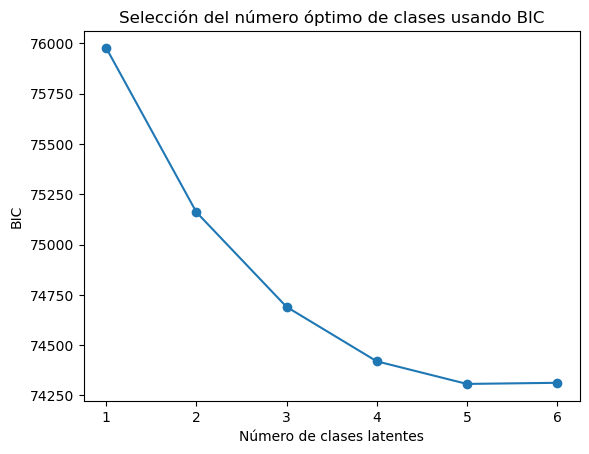

{'tags': ['hide_input']}

In [22]:
#Escoger según BIC
bic_list = []
models = []
for n_classes in range(1, 7):
    model = StepMix(n_components=n_classes, measurement='continuous', random_state=42)
    model.fit(X)
    bic = model.bic(X)
    bic_list.append(bic)
    models.append(model)


plt.plot(range(1, 7), bic_list, marker='o')
plt.xlabel('Número de clases latentes')
plt.ylabel('BIC')
plt.title('Selección del número óptimo de clases usando BIC')
plt.show()

{"tags": ["hide_input"]}

Escogemos correr un modelo con 3 clases latentes.

In [23]:
model = StepMix(n_components=3, measurement="continuous", verbose=1, random_state=123).fit(X)

{"tags": ["hide_input"]}

Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:10<00:00, 10.21s/it, max_LL=-3.73e+4, max_avg_LL=-1.53]

MODEL REPORT
    Measurement model parameters
          model_name            gaussian_diag                
          class_no                          0       1       2
          param       variable                               
          covariances feature_0        0.5068  0.1004  0.9993
          means       feature_0        1.1622  2.4464  0.0527
    Class weights
        Class 1 : 0.43
        Class 2 : 0.12
        Class 3 : 0.44
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 24444
    Number of latent classes      : 3
    Number of estimated parameters: 8
    Log-likelihood (LL)           : -37304.6290
    -2LL                          : 74609.2581
    Average LL                    : -1.5261
    AIC                           : 74625.26
    BIC                           : 74690.09
    CAIC                          : 74698.09
    Sample-Size Adjusted BIC      : 74745.50
    Entropy                       : 14277.7426
 

{'tags': ['hide_input']}

Basándonos en estos resultados, podríamos describir al grupo 1 como aquellos niños con sobrepeso, al grupo 2 como los niños con obesidad y al grupo 3 como los niños con un peso promedio, aunque este también incluye esos relativamente pocos caso de bajo peso y desnutrición.

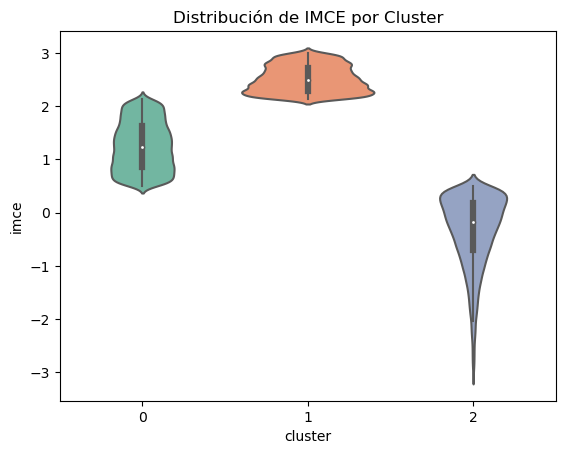

{'tags': ['hide_input']}

In [24]:
class_labels = model.predict(X)
df['cluster'] = class_labels
sns.violinplot(x='cluster', y='imce', data=df, palette='Set2')
plt.title('Distribución de IMCE por Cluster')
plt.show()


{"tags": ["hide_input"]}

# Pregunta 6
Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

Además de nuestros 3 factores latentes, intentaremos explicar el imce usando las variables act_física ya que esto debería de llevar al imce a un lugar promedio, educp y educm ya que una mayor escolarización de los padres podría indicar que son más pudientes y concientes de la salud de sus hijos, lo que podría llevar a que sus hijos tengan un imce correcto, la variable madre_work, ya que una madre en hogar debería estar más conciente de la salud y la alimentación de su hijo y la variable área por los comportamientos variables de los ni{os dependiendo si viven en un área urbana o rural.

In [76]:
modelo = """
# Modelo de medición (factores latentes)
DS =~ sk1+sk2+sk3+sk4
CyC =~ sk9+sk10+sk11+sk12+sk13
IS =~ sk5+sk6+sk8

# Modelo estructural
imce ~ DS + CyC + IS + act_fisica + educm +educp + madre_work + area

"""
model = Model(modelo)
model.fit(df)

resumen = model.inspect()
imce_params=resumen[resumen["lval"]=="imce"]
print(imce_params)

model_cfa = semopy.Model(modelo);
out = model_cfa.fit(df);
print(out)

{"tags": ["hide_input"]}

    lval  op        rval  Estimate  Std. Err     z-value   p-value
12  imce   ~          DS -0.099094  0.067501    -1.46803  0.142096
13  imce   ~         CyC -0.022428  0.033734   -0.664848  0.506148
14  imce   ~          IS  0.079710  0.038192    2.087091   0.03688
15  imce   ~  act_fisica -0.017088  0.006844   -2.496741  0.012534
16  imce   ~       educm -0.001449  0.003421     -0.4236  0.671857
17  imce   ~       educp -0.011957   0.00335   -3.569386  0.000358
18  imce   ~  madre_work  0.043617  0.008055    5.415096       0.0
19  imce   ~        area -0.110301  0.026516    -4.15987  0.000032
26  imce  ~~        imce  1.304857  0.011809  110.495515       0.0
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.207
Number of iterations: 47
Params: 1.946 1.705 1.923 1.341 1.249 1.100 1.263 1.013 1.177 -0.099 -0.022 0.080 -0.017 -0.001 -0.012 0.044 -0.110 0.143 0.046 0.085 0.044 0.052 0.153 1.305 0.091 0.595 

{'tags': ['hide_input']}

El TLI y CFI son >0.9 y el RMSEA es<0.05, por lo que es un modelo válido.

In [72]:
from semopy import calc_stats

stats = calc_stats(model)
print(stats[['TLI', 'CFI', 'RMSEA', 'AIC', 'BIC']])

{"tags": ["hide_input"]}

            TLI       CFI     RMSEA        AIC         BIC
Value  0.925516  0.936359  0.038589  71.586906  363.335948


{'tags': ['hide_input']}

In [77]:
model_cfa.inspect(mode='list', what="names", std_est=True)

{"tags": ["hide_input"]}

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk1,~,DS,1.000000,0.570460,-,-,-
1,sk2,~,DS,1.945652,0.640307,0.02793,69.660854,0.0
2,sk3,~,DS,1.705051,0.627992,0.024752,68.884428,0.0
3,sk4,~,DS,1.922992,0.713111,0.026182,73.445841,0.0
4,sk9,~,CyC,1.000000,0.587446,-,-,-
5,sk10,~,CyC,1.341044,0.549099,0.021009,63.832715,0.0
6,sk11,~,CyC,1.249207,0.731247,0.016698,74.812487,0.0
7,sk12,~,CyC,1.099588,0.532632,0.017601,62.47376,0.0
8,sk13,~,CyC,1.263266,0.493502,0.021386,59.070694,0.0
9,sk5,~,IS,1.000000,0.714061,-,-,-


In [73]:
semopy.semplot(model, "modelo.png")

{"tags": ["hide_input"]}

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

# Pregunta 7
Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?

In [78]:
resultados_clusters = {}

for c in df['cluster'].unique():
    print(f"\n Estimando modelo para cluster {c}")
    df_cluster = df[df['cluster'] == c]
    
    
    model = Model(modelo)
    model.fit(df_cluster)
    
    
    estimates = model.inspect()
    imce_params = estimates[estimates['lval'] == 'imce']
    stats = calc_stats(model)
    
    resultados_clusters[c] = {
        'model': model,
        'estimates': estimates,
        'stats': stats
    }

    
    print(stats[['TLI', 'CFI', 'RMSEA']])
    print(imce_params)
    
{"tags": ["hide_input"]}


 Estimando modelo para cluster 0
            TLI       CFI     RMSEA
Value  0.924433  0.935433  0.039196
    lval  op        rval  Estimate  Std. Err    z-value   p-value
12  imce   ~          DS  0.005328  0.041202   0.129307  0.897115
13  imce   ~         CyC -0.022465  0.019833  -1.132696  0.257342
14  imce   ~          IS  0.028405  0.023894   1.188824  0.234509
15  imce   ~  act_fisica -0.008334  0.003973  -2.097307  0.035966
16  imce   ~       educm -0.000618  0.001967  -0.313998  0.753523
17  imce   ~       educp -0.004555  0.001937  -2.351326  0.018707
18  imce   ~  madre_work  0.001521  0.004681   0.324953  0.745217
19  imce   ~        area  0.019632  0.015033   1.305948   0.19157
26  imce  ~~        imce  0.208734  0.002743  76.088604       0.0

 Estimando modelo para cluster 2
           TLI       CFI     RMSEA
Value  0.92769  0.938216  0.037797
    lval  op        rval  Estimate  Std. Err    z-value   p-value
12  imce   ~          DS -0.028691  0.065477  -0.438179  0.66125

{'tags': ['hide_input']}

La estructura de factores latentes y su relación con imce tiene buen ajuste general en todos los clusters (TLI, CFI, RMSEA). Sin embargo, ninguna de las variables predictoras consideradas explica significativamente imce dentro de los clusters. Esto indica que imce podría depender de otros factores no medidos en este análisis, o que la relación con las variables actuales es débil. Ajustar por clusters no revela diferencias sustanciales en la importancia de las variables predictoras para imce.

In [ ]:
!jupyter nbconvert --to pdf --TagRemovePreprocessor.enabled=True --TagRemovePreprocessor.remove_input_tags="['hide_input']" Tarea3_Meza_Núñez.ipynb

0.8151444833854218

0.9261328318016957